## Cell 1 - Setup

In [1]:
# !pip install matplotlib
# !pip uninstall torch torchvision torchaudio -y
# # check current version
# !pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130 --upgrade
# import torch
# print(torch.__version__)
# print(torch.cuda.get_device_capability())

In [2]:
import os, sys
if not os.path.exists('DiT'):
    !git clone https://github.com/facebookresearch/DiT.git -q
sys.path.insert(0, os.path.abspath('DiT'))
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from diffusers.models import AutoencoderKL
from torchvision import transforms
from datasets import load_dataset
from tqdm import tqdm
from models import DiT_models
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
print(f'Device : {device}')
if device == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


Device : cuda
GPU    : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM   : 102.0 GB


## Cell 2 - Model Loading (Frozen Backbone)

In [3]:
CKPT = 'DiT-XL-2-256x256.pt'
if not os.path.exists(CKPT):
    !wget -q --show-progress https://dl.fbaipublicfiles.com/DiT/models/DiT-XL-2-256x256.pt

dit = DiT_models['DiT-XL/2'](input_size=32).to(device)
state = torch.load(CKPT, map_location=device)
dit.load_state_dict(state.get('model', state))

# freeze backbone
for p in dit.parameters():
    p.requires_grad = False
dit.eval()

# patch TimestepEmbedder for BF16
import DiT.models as dit_models
_orig_te = dit_models.TimestepEmbedder.forward
def _patched_te(self, t):
    t_freq = self.timestep_embedding(t, self.frequency_embedding_size)
    t_freq = t_freq.to(self.mlp[0].weight.dtype)
    return self.mlp(t_freq)
dit_models.TimestepEmbedder.forward = _patched_te

# patch DiT forward for BF16 input cast
_orig_dit_fwd = dit_models.DiT.forward
def _patched_dit_fwd(self, x, t, y):
    x = x.to(self.x_embedder.proj.weight.dtype)
    return _orig_dit_fwd(self, x, t, y)
dit_models.DiT.forward = _patched_dit_fwd

vae = AutoencoderKL.from_pretrained('stabilityai/sd-vae-ft-mse').to(device)
vae.eval()
for p in vae.parameters():
    p.requires_grad = False

hidden_dim  = dit.x_embedder.proj.out_channels
IN_CHANNELS = 4
print(f'DiT-XL/2: {sum(p.numel() for p in dit.parameters())/1e6:.0f}M params, frozen={not any(p.requires_grad for p in dit.parameters())}')


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


DiT-XL/2: 675M params, frozen=True


## Cell 3 - Latent Cache

In [4]:
LATENT_CACHE_FILE = 'latents_tiny.pt'
N_CACHE = 512
ENCODE_BATCH = 32

if os.path.exists(LATENT_CACHE_FILE):
    cache = torch.load(LATENT_CACHE_FILE, map_location='cpu')
    latent_cache = cache['latents']
    label_cache  = cache['labels']
    print(f'Loaded: {latent_cache.shape}')
else:
    print('Building cache from tiny-imagenet...')
    ds = load_dataset('zh-plus/tiny-imagenet', split='valid', streaming=True)
    tf = transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(256),
        transforms.ToTensor(), transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
    ])
    all_latents, all_labels, batch_imgs, batch_labels = [], [], [], []
    for sample in ds:
        img = sample['image'].convert('RGB')
        batch_imgs.append(tf(img))
        batch_labels.append(sample['label'])
        if len(batch_imgs) == ENCODE_BATCH:
            with torch.no_grad():
                lat = vae.encode(torch.stack(batch_imgs).to(device)).latent_dist.sample() * 0.18215
            all_latents.append(lat.cpu())
            all_labels.extend(batch_labels)
            batch_imgs, batch_labels = [], []
            print(f'  {len(all_labels)}/{N_CACHE}', end='\r')
            if len(all_labels) >= N_CACHE: break
    latent_cache = torch.cat(all_latents)[:N_CACHE]
    label_cache  = torch.tensor(all_labels[:N_CACHE])
    torch.save({'latents': latent_cache, 'labels': label_cache}, LATENT_CACHE_FILE)
    print(f'\nSaved {latent_cache.shape[0]} latents')

latent_cache = latent_cache.to(device)
label_cache  = label_cache.to(device)
print(f'Cache: {latent_cache.shape}, dtype={latent_cache.dtype}, device={latent_cache.device}')
dit          = dit.to(device=device, dtype=torch.bfloat16)
print(f'Cache: {latent_cache.shape}, dtype={latent_cache.dtype}, device={latent_cache.device}')
# keep everything float32 — no BF16 conversion


Loaded: torch.Size([512, 4, 32, 32])
Cache: torch.Size([512, 4, 32, 32]), dtype=torch.float32, device=cuda:0
Cache: torch.Size([512, 4, 32, 32]), dtype=torch.float32, device=cuda:0


## Cell 4 - Architecture

In [5]:
def modulate(x, shift, scale):
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

def _run_attn_half(block, x, c):
    shift_msa, scale_msa, gate_msa, shift_mlp, scale_mlp, gate_mlp = block.adaLN_modulation(c).chunk(6, dim=1)
    attn_out    = block.attn(modulate(block.norm1(x), shift_msa, scale_msa))
    x_post_attn = x + gate_msa.unsqueeze(1) * attn_out
    return x_post_attn, (shift_mlp, scale_mlp, gate_mlp)

def _run_mlp_half(block, x, mlp_params):
    shift_mlp, scale_mlp, gate_mlp = mlp_params
    return x + gate_mlp.unsqueeze(1) * block.mlp(modulate(block.norm2(x), shift_mlp, scale_mlp))

class TokenPredictor(nn.Module):
    def __init__(self, d_model, bottleneck=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, bottleneck),
            nn.GELU(), nn.Linear(bottleneck, 1),
        )
    def forward(self, x, temperature=1.0):
        logits = self.mlp(x)
        pair   = torch.cat([logits, -logits], dim=-1)
        hard   = F.gumbel_softmax(pair, tau=temperature, hard=True)
        return hard[..., 1], logits

class PruningWrapper(nn.Module):
    def __init__(self, block, predictor):
        super().__init__()
        self.block           = block
        self.predictor       = predictor
        self.pruning_enabled = True
        self._last_mask      = None
        self._live_mask      = None
        self._temperature    = 1.0
    def forward(self, x, c):
        if not self.pruning_enabled:
            self._live_mask = None
            return self.block(x, c)
        B, N, D = x.shape
        x_post_attn, mlp_params = _run_attn_half(self.block, x, c)
        keep_mask, _ = self.predictor(x_post_attn, self._temperature)
        self._live_mask = keep_mask
        self._last_mask = keep_mask.detach()
        out = torch.zeros_like(x_post_attn)
        for b in range(B):
            idx  = keep_mask[b].detach().bool()
            N_k  = idx.sum().item()
            mp_b = tuple(p[b].unsqueeze(0) for p in mlp_params)
            if N_k == 0 or N_k == N:
                out[b] = _run_mlp_half(self.block, x_post_attn[b].unsqueeze(0), mp_b).squeeze(0)
            else:
                ii = idx.nonzero(as_tuple=True)[0]
                out_k = _run_mlp_half(self.block, x_post_attn[b,ii,:].unsqueeze(0), mp_b).squeeze(0)
                out_b = x_post_attn[b].clone()
                out_b[ii] = out_k
                out[b] = out_b
        return out

def set_pruning_mode(model, enabled):
    for b in model.blocks:
        if isinstance(b, PruningWrapper): b.pruning_enabled = enabled

def get_all_masks(model, live=False):
    attr = '_live_mask' if live else '_last_mask'
    return [getattr(b, attr) for b in model.blocks
            if isinstance(b, PruningWrapper) and getattr(b, attr) is not None]

print('Architecture defined.')


Architecture defined.


## Cell 5 - Wrap Layers

In [6]:
PRUNING_LAYERS = list(range(0, 28, 2))

for idx in PRUNING_LAYERS:
    b = dit.blocks[idx]
    while isinstance(b, PruningWrapper): b = b.block
    dit.blocks[idx] = b

for idx in PRUNING_LAYERS:
    pred = TokenPredictor(hidden_dim, 64).to(device).to(torch.bfloat16)
    dit.blocks[idx] = PruningWrapper(dit.blocks[idx], pred)

all_parasites = [b.predictor for b in dit.blocks if isinstance(b, PruningWrapper)]
n_gate = sum(p.numel() for pp in all_parasites for p in pp.parameters())
print(f'Gated layers : {PRUNING_LAYERS}')
print(f'Gate params  : {n_gate/1e6:.2f}M')
print(f'Depth check  : {type(dit.blocks[0]).__name__} -> {type(dit.blocks[0].block).__name__}')


Gated layers : [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26]
Gate params  : 1.07M
Depth check  : PruningWrapper -> DiTBlock


## Cell 6 - Optimizer & Config

In [7]:
from diffusion import create_diffusion
from torch.optim.lr_scheduler import CosineAnnealingLR

STEPS               = 5000
BATCH_SIZE          = 4
LR_GATE             = 1e-4
TARGET_RATIO        = 0.5
LAMBDA_DIT          = 1.0
LAMBDA_SPARSE       = 0.5
TEMP_START          = 2.0
TEMP_END            = 0.5
TEACHER_INTERVAL    = 200
CHECKPOINT_INTERVAL = 500
CHECKPOINT_PATH     = 'frozen_sdt_resume.pt'

diffusion = create_diffusion(timestep_respacing='')
optimizer = torch.optim.Adam(
    [p for pp in all_parasites for p in pp.parameters()], lr=LR_GATE
)
scheduler = CosineAnnealingLR(optimizer, T_max=STEPS, eta_min=1e-7)
print(f'STEPS={STEPS} | BATCH={BATCH_SIZE} | LR={LR_GATE} | TARGET={TARGET_RATIO}')


STEPS=5000 | BATCH=4 | LR=0.0001 | TARGET=0.5


In [8]:
# force entire model back to float32
dit = dit.float()

# verify
print(f"Model dtype : {next(dit.parameters()).dtype}")
print(f"Cache dtype : {latent_cache.dtype}")
print(f"x_embedder bias dtype: {dit.x_embedder.proj.bias.dtype}")

Model dtype : torch.float32
Cache dtype : torch.float32
x_embedder bias dtype: torch.float32


## Cell 7 - Training Loop (Frozen, Auto-Resume)

In [9]:
resume_step = 0
last_teacher_gap = 0.0

if os.path.exists(CHECKPOINT_PATH):
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    dit.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optimizer_state'])
    scheduler.load_state_dict(ckpt['scheduler_state'])
    history          = ckpt['history']
    resume_step      = ckpt['step'] + 1
    last_teacher_gap = ckpt['last_teacher_gap']
    print(f'Resuming from step {resume_step}/{STEPS}')
else:
    history = {'loss_dit':[],'loss_sparse':[],'loss_total':[],
               'loss_teacher':[],'keep_ratio':[],'temperature':[]}
    print('Starting from step 0')

dit.eval()
for pp in all_parasites: pp.train()

pbar = tqdm(range(resume_step, STEPS))
for step in pbar:
    optimizer.zero_grad()

    frac        = step / max(STEPS - 1, 1)
    temperature = TEMP_START * (TEMP_END / TEMP_START) ** frac
    for pp in all_parasites: pp._temperature = temperature

    idx_batch = torch.randint(0, latent_cache.shape[0], (BATCH_SIZE,))
    x0        = latent_cache[idx_batch]
    y         = label_cache[idx_batch]
    t         = torch.randint(0, 1000, (BATCH_SIZE,), device=device)
    noise     = torch.randn_like(x0)
    z_t       = diffusion.q_sample(x0, t, noise=noise)

    if step % TEACHER_INTERVAL == 0:
        set_pruning_mode(dit, enabled=False)
        with torch.inference_mode():
            teacher_out        = dit(z_t, t, y)
            noise_pred_teacher = teacher_out[:, :IN_CHANNELS, :, :]

    set_pruning_mode(dit, enabled=True)
    student_out        = dit(z_t, t, y)
    noise_pred_student = student_out[:, :IN_CHANNELS, :, :]
    loss_dit           = F.mse_loss(noise_pred_student, noise)

    if step % TEACHER_INTERVAL == 0:
        last_teacher_gap = F.mse_loss(
            noise_pred_student.detach(), noise_pred_teacher
        ).item()

    live_masks  = get_all_masks(dit, live=True)
    live_ratio  = torch.stack([m.float().mean() for m in live_masks]).mean()
    loss_sparse = (live_ratio - TARGET_RATIO) ** 2
    total_loss  = LAMBDA_DIT * loss_dit + LAMBDA_SPARSE * loss_sparse
    total_loss.backward()

    torch.nn.utils.clip_grad_norm_(
        [p for pp in all_parasites for p in pp.parameters()], max_norm=1.0
    )
    optimizer.step()
    scheduler.step()

    log_ratio = torch.stack(
        [m.float().mean() for m in get_all_masks(dit, live=False)]
    ).mean().item()

    history['loss_dit'].append(loss_dit.item())
    history['loss_sparse'].append(loss_sparse.item())
    history['loss_total'].append(total_loss.item())
    history['loss_teacher'].append(last_teacher_gap)
    history['keep_ratio'].append(log_ratio)
    history['temperature'].append(temperature)

    pbar.set_description(
        f'dit={loss_dit.item():.4f} | sp={loss_sparse.item():.4f} | '
        f'gap={last_teacher_gap:.4f} | kept={log_ratio*100:.1f}%'
    )

    if step % CHECKPOINT_INTERVAL == 0 and step > resume_step:
        torch.save({
            'step': step, 'model_state': dit.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'scheduler_state': scheduler.state_dict(),
            'history': history, 'last_teacher_gap': last_teacher_gap,
        }, CHECKPOINT_PATH)
        pbar.write(f'  Checkpoint saved at step {step}')

print(f'Done | dit={history["loss_dit"][-1]:.4f} | kept={history["keep_ratio"][-1]*100:.1f}%')


Resuming from step 4501/5000


dit=0.4236 | sp=0.0000 | gap=0.1475 | kept=49.6%: 100%|██████████| 499/499 [00:13<00:00, 35.72it/s]

Done | dit=0.4236 | kept=49.6%


## Cell 8 - Training Curves

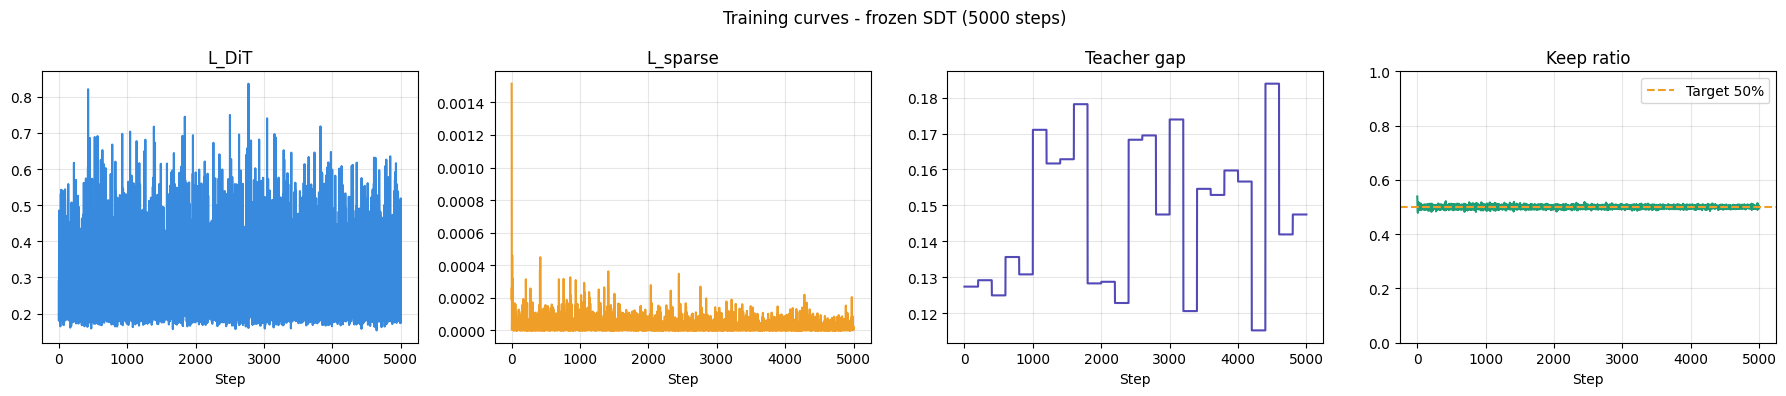

Saved: training_curves.png


In [10]:
steps = list(range(1, len(history['loss_dit']) + 1))
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].plot(steps, history['loss_dit'],     color='#378ADD'); axes[0].set_title('L_DiT')
axes[1].plot(steps, history['loss_sparse'],  color='#EF9F27'); axes[1].set_title('L_sparse')
axes[2].plot(steps, history['loss_teacher'], color='#534AB7'); axes[2].set_title('Teacher gap')
axes[3].plot(steps, history['keep_ratio'],   color='#1D9E75')
axes[3].axhline(0.5, color='#EF9F27', linestyle='--', label='Target 50%')
axes[3].set_ylim(0, 1); axes[3].set_title('Keep ratio'); axes[3].legend()
for ax in axes: ax.set_xlabel('Step'); ax.grid(True, alpha=0.3)
plt.suptitle(f'Training curves - frozen SDT ({len(steps)} steps)', fontsize=12)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')


## Cell 9 - FLOP Benchmark

In [11]:
from fvcore.nn import FlopCountAnalysis
# match model dtype automatically
model_dtype = next(dit.parameters()).dtype

z_b = torch.randn(1, 4, 32, 32, device=device, dtype=model_dtype)
t_b = torch.randint(0, 1000, (1,), device=device)
y_b = torch.zeros(1, dtype=torch.long, device=device)
REPS = 30
starter = torch.cuda.Event(enable_timing=True)
ender   = torch.cuda.Event(enable_timing=True)






set_pruning_mode(dit, enabled=False); dit.eval()
with torch.no_grad():
    for _ in range(10): _ = dit(z_b, t_b, y_b)
    torch.cuda.synchronize(); starter.record()
    for _ in range(REPS): _ = dit(z_b, t_b, y_b)
    ender.record(); torch.cuda.synchronize()
ms_t = starter.elapsed_time(ender) / REPS

set_pruning_mode(dit, enabled=True)
with torch.no_grad():
    for _ in range(10): _ = dit(z_b, t_b, y_b)
    torch.cuda.synchronize(); starter.record()
    for _ in range(REPS): _ = dit(z_b, t_b, y_b)
    ender.record(); torch.cuda.synchronize()
ms_s = starter.elapsed_time(ender) / REPS

try:
    set_pruning_mode(dit, enabled=False)
    gmac_t = FlopCountAnalysis(dit, (z_b, t_b, y_b)).total() / 1e9
    set_pruning_mode(dit, enabled=True)
    gmac_s = FlopCountAnalysis(dit, (z_b, t_b, y_b)).total() / 1e9
    print(f'Teacher: {gmac_t:.2f} GMACs | Student: {gmac_s:.2f} GMACs | Reduction: {(1-gmac_s/gmac_t)*100:.1f}%')
except Exception as e:
    print(f'fvcore failed: {e}')
print(f'Teacher: {ms_t:.2f} ms | Student: {ms_s:.2f} ms | Speedup: {ms_t/ms_s:.3f}x')


Unsupported operator aten::add encountered 172 time(s)
Unsupported operator aten::mul encountered 115 time(s)
Unsupported operator aten::div encountered 1 time(s)
Unsupported operator aten::exp encountered 1 time(s)
Unsupported operator aten::cos encountered 1 time(s)
Unsupported operator aten::sin encountered 1 time(s)
Unsupported operator aten::silu encountered 30 time(s)
Unsupported operator aten::embedding encountered 1 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 28 time(s)
Unsupported operator aten::gelu encountered 28 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
blocks.0.block.attn.attn_drop, blocks.0.predictor, blocks.0.predictor.mlp, blocks.0.predictor.mlp.0, blocks.

Teacher: 114.46 GMACs | Student: 96.09 GMACs | Reduction: 16.0%
Teacher: 6.26 ms | Student: 8.69 ms | Speedup: 0.720x


## Cell 10 - Qualitative Evaluation

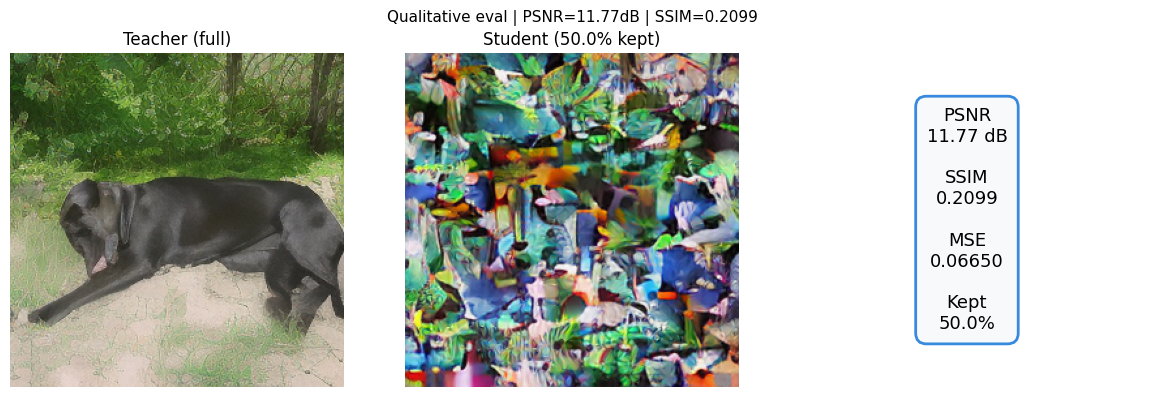

PSNR=11.77dB | SSIM=0.2099 | MSE=0.06650 | Kept=50.0%


In [12]:
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

model_dtype = next(dit.parameters()).dtype   # auto-detect — works for fp32 and bf16

def decode(lat):
    with torch.no_grad():
        px = vae.decode(lat.float() / 0.18215).sample
    return ((px[0].permute(1,2,0).cpu().numpy() + 1) / 2).clip(0, 1)

diff_eval = create_diffusion(timestep_respacing='ddim50')
z  = torch.randn(1, 4, 32, 32, device=device, dtype=model_dtype)   # match model dtype
ye = torch.tensor([208], device=device)

set_pruning_mode(dit, enabled=False); dit.eval()
with torch.no_grad():
    lat_t = diff_eval.ddim_sample_loop(dit, (1,4,32,32), noise=z.clone(),
                model_kwargs={'y': ye}, device=device, progress=False)

set_pruning_mode(dit, enabled=True)
with torch.no_grad():
    lat_s = diff_eval.ddim_sample_loop(dit, (1,4,32,32), noise=z.clone(),
                model_kwargs={'y': ye}, device=device, progress=False)

img_t = decode(lat_t); img_s = decode(lat_s)
psnr  = psnr_fn(img_t, img_s, data_range=1.0)
ssim  = ssim_fn(img_t, img_s, data_range=1.0, channel_axis=2)
mse   = float(np.mean((img_t - img_s) ** 2))
masks = get_all_masks(dit)
kept  = sum(m.mean().item() for m in masks) / len(masks) * 100

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_t); axes[0].set_title('Teacher (full)'); axes[0].axis('off')
axes[1].imshow(img_s); axes[1].set_title(f'Student ({kept:.1f}% kept)'); axes[1].axis('off')
axes[2].axis('off')
axes[2].text(0.5, 0.5,
    f'PSNR\n{psnr:.2f} dB\n\nSSIM\n{ssim:.4f}\n\nMSE\n{mse:.5f}\n\nKept\n{kept:.1f}%',
    ha='center', va='center', fontsize=13, transform=axes[2].transAxes,
    bbox=dict(boxstyle='round,pad=0.6', facecolor='#f8f9fa', edgecolor='#378ADD', linewidth=2)
)
plt.suptitle(f'Qualitative eval | PSNR={psnr:.2f}dB | SSIM={ssim:.4f}', fontsize=11)
plt.tight_layout()
plt.savefig('qualitative_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'PSNR={psnr:.2f}dB | SSIM={ssim:.4f} | MSE={mse:.5f} | Kept={kept:.1f}%')

## Cell 11 - Saliency Experiments (All 4)

Experiment 1: cross-timestep...
  t=900 done
  t=700 done
  t=500 done
  t=300 done
  t=100 done


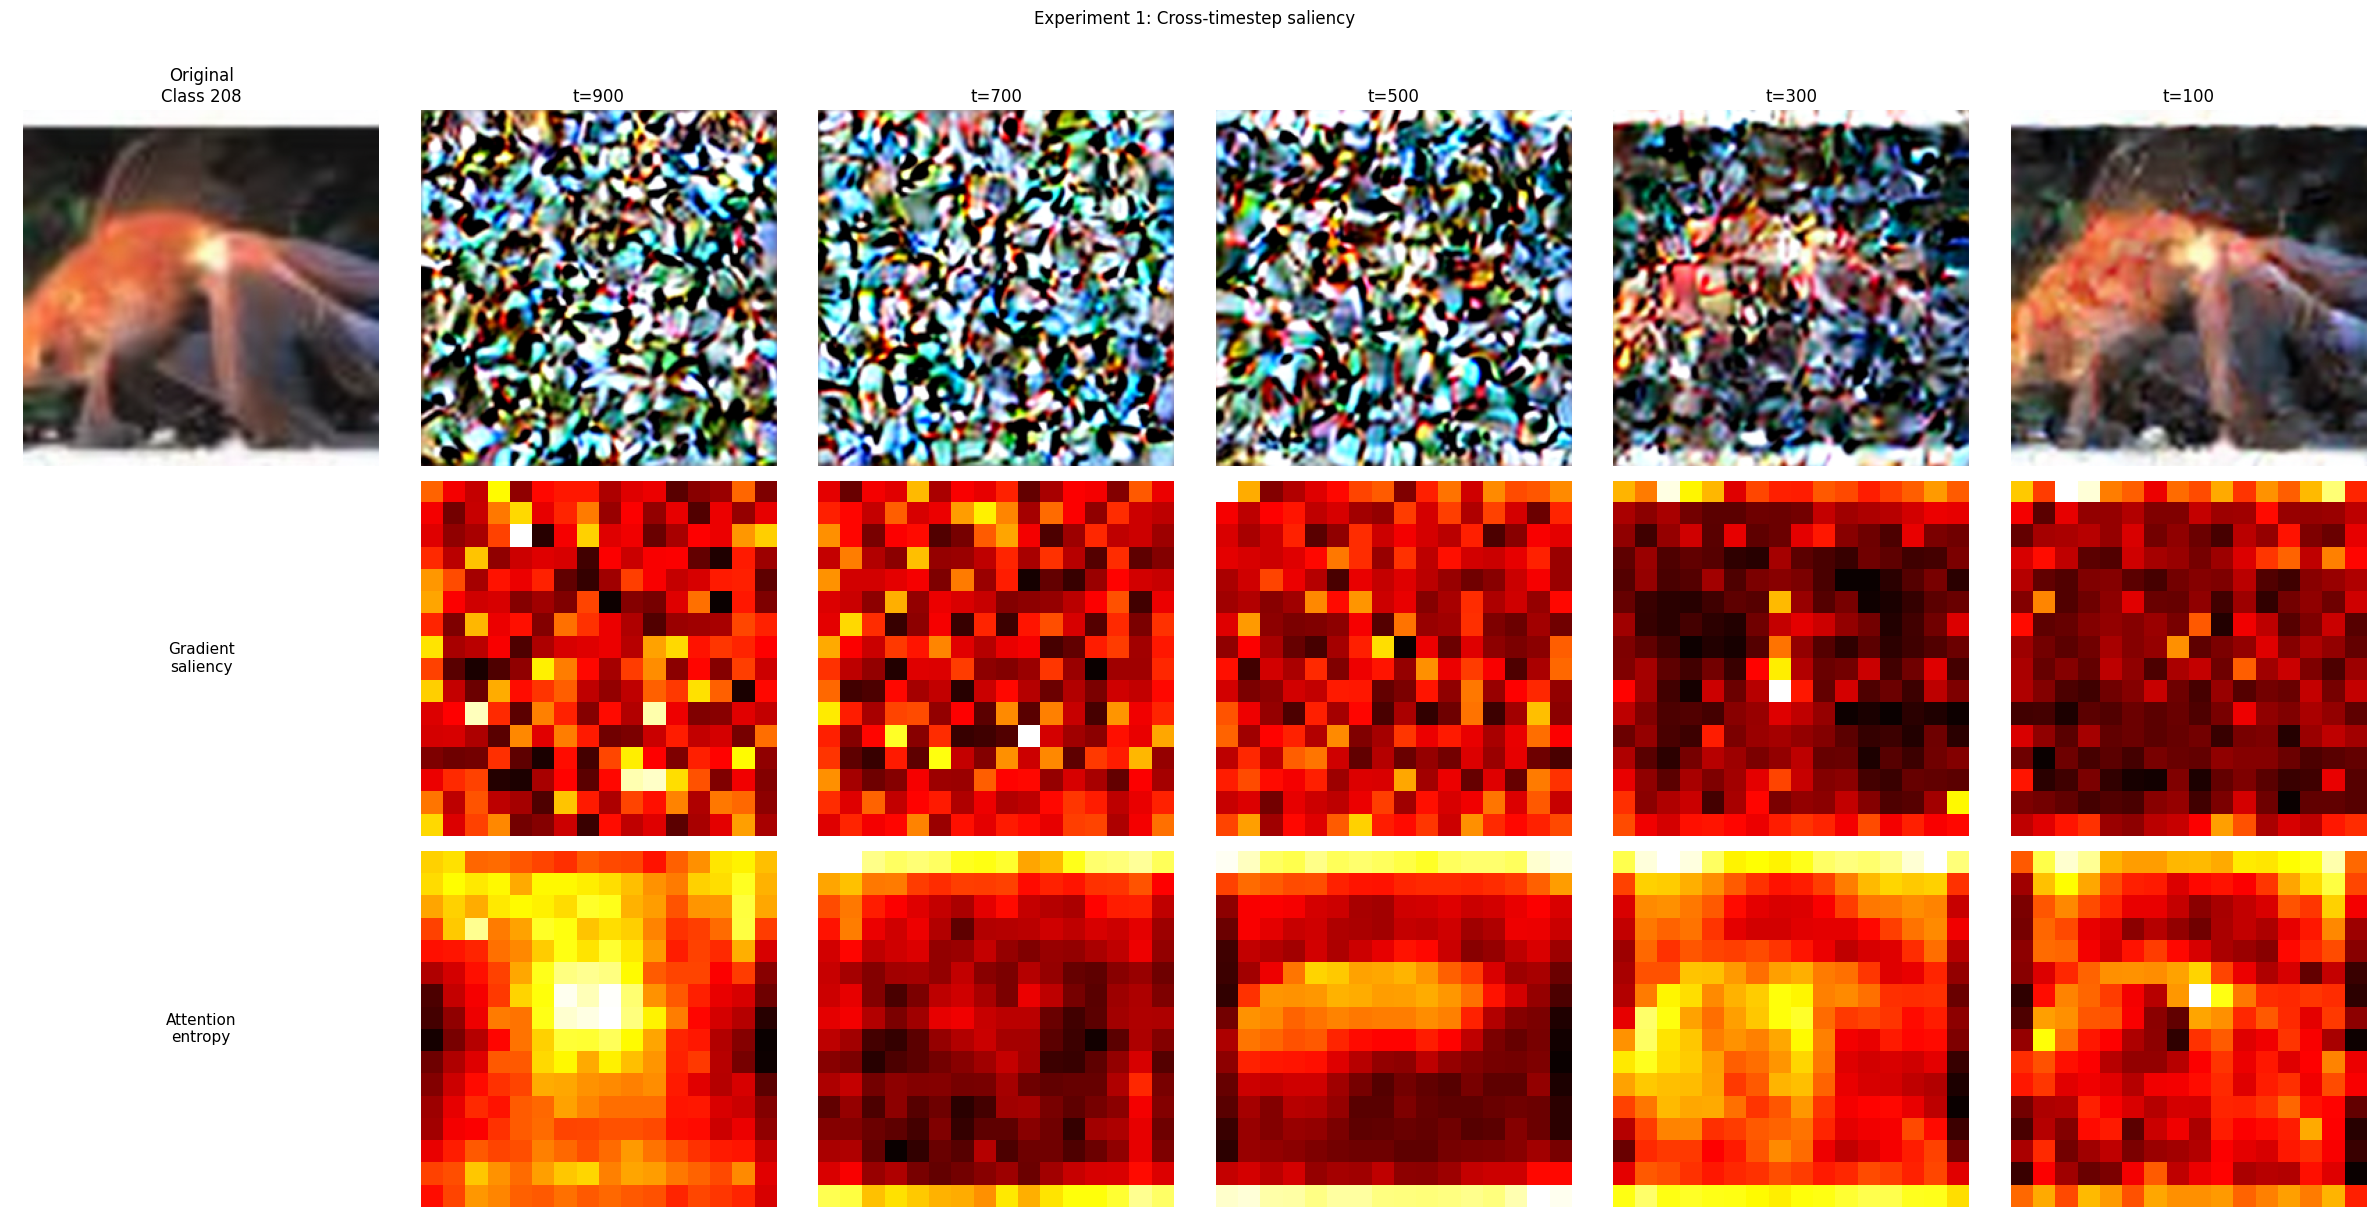

Experiment 2: gate vs saliency IoU...


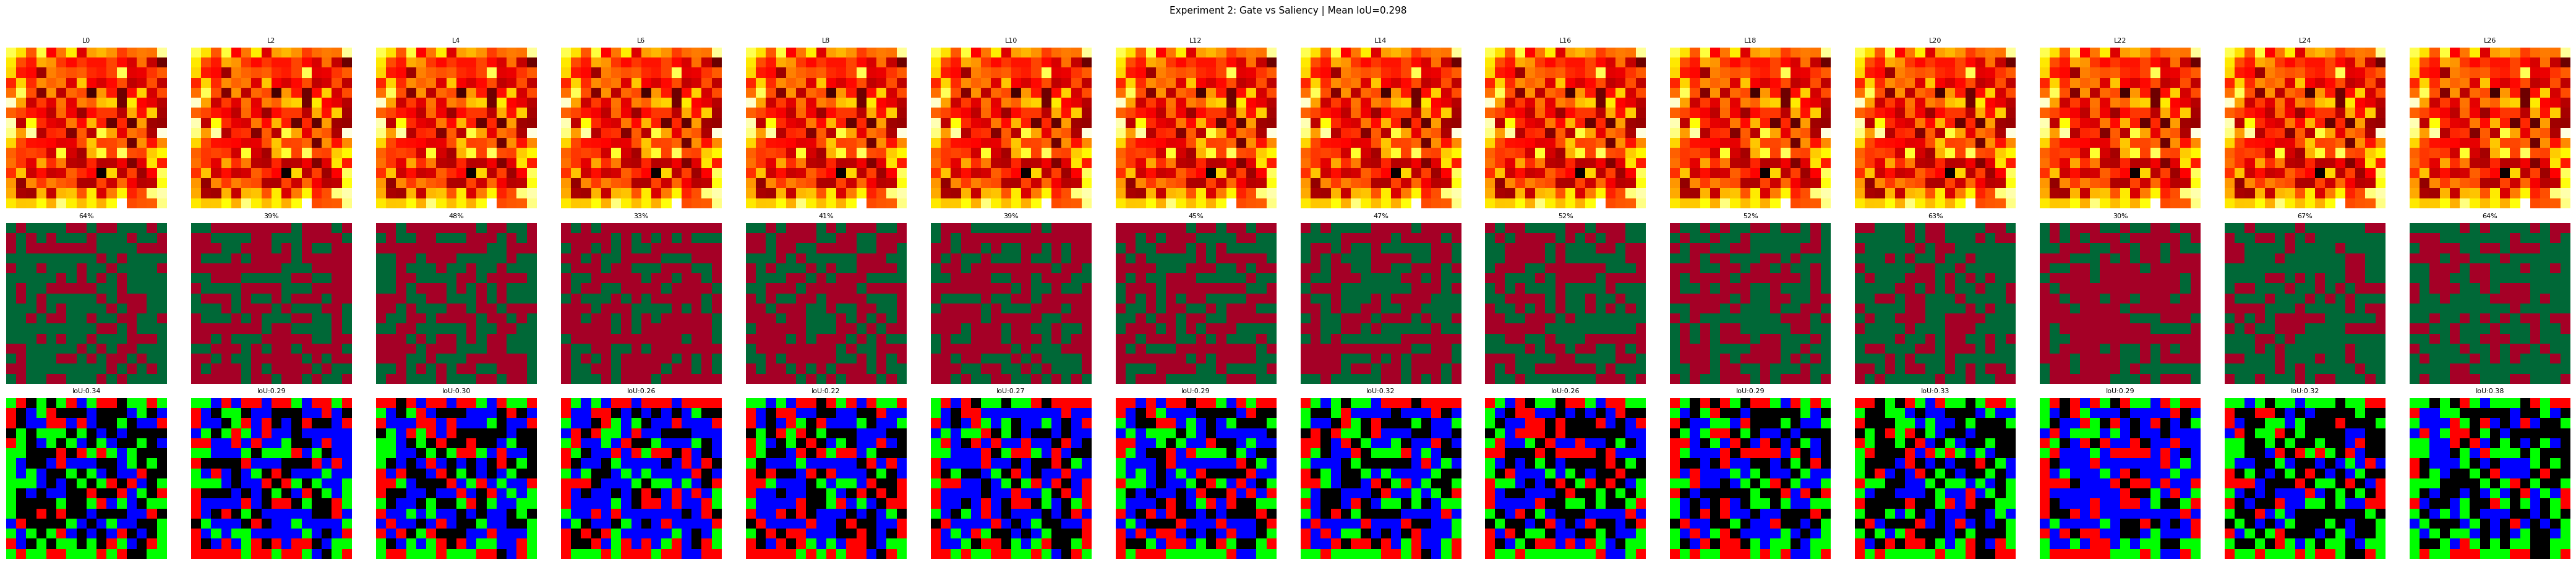

Mean IoU: 0.2979 (random ~0.33)
Saliency min=0.000 max=1.000 mean=0.479
Tokens marked important (>0.5): 107 / 256
Experiment 3: per-layer entropy...


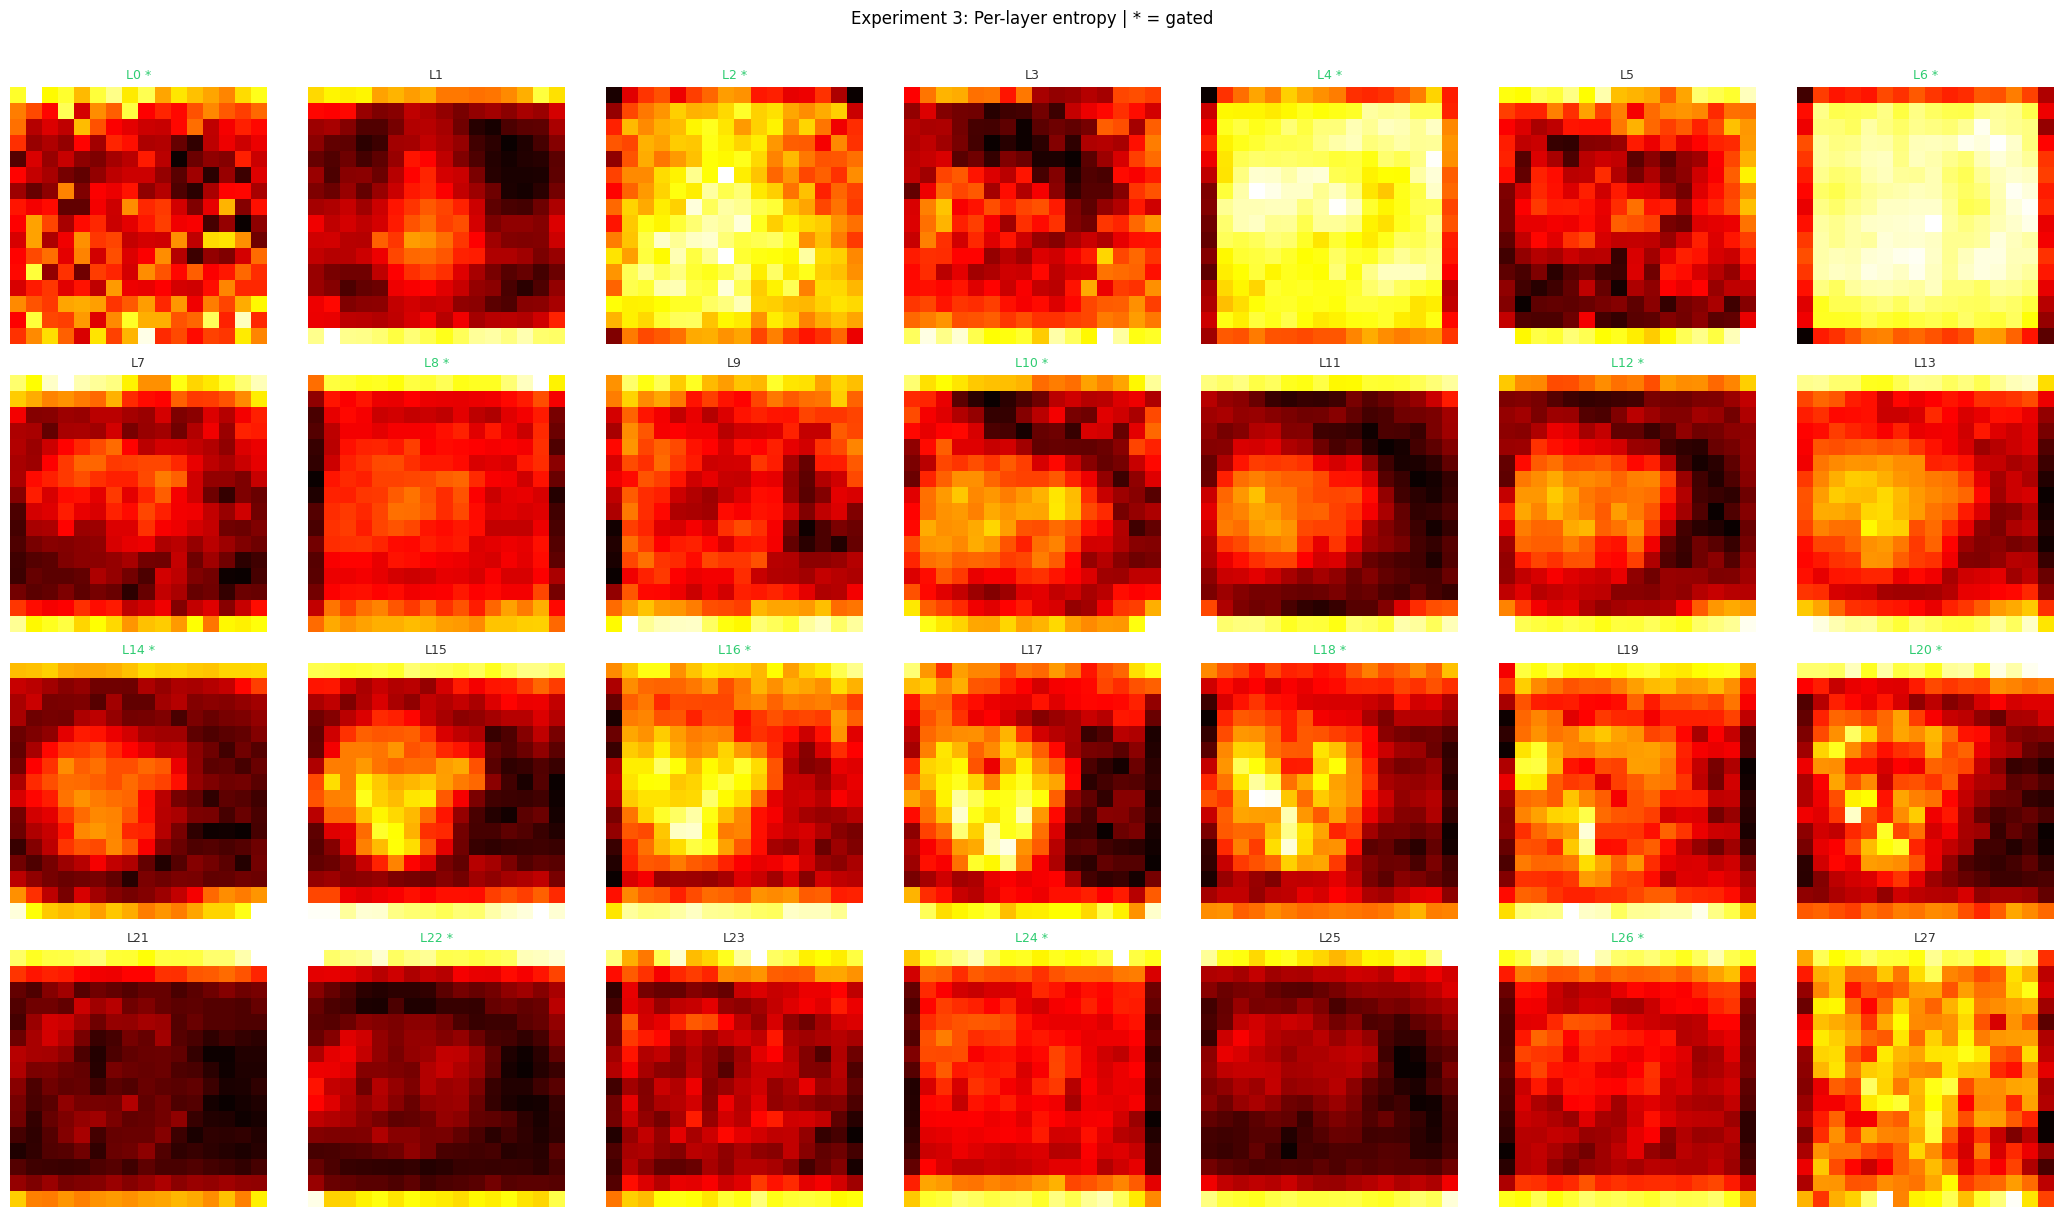

Experiment 4: DDPM vs DDIM...
  DDPM t=100 done
  DDPM t=300 done
  DDPM t=500 done
  DDPM t=700 done
  DDPM t=900 done
  DDIM t=100 done
  DDIM t=300 done
  DDIM t=500 done
  DDIM t=700 done
  DDIM t=900 done


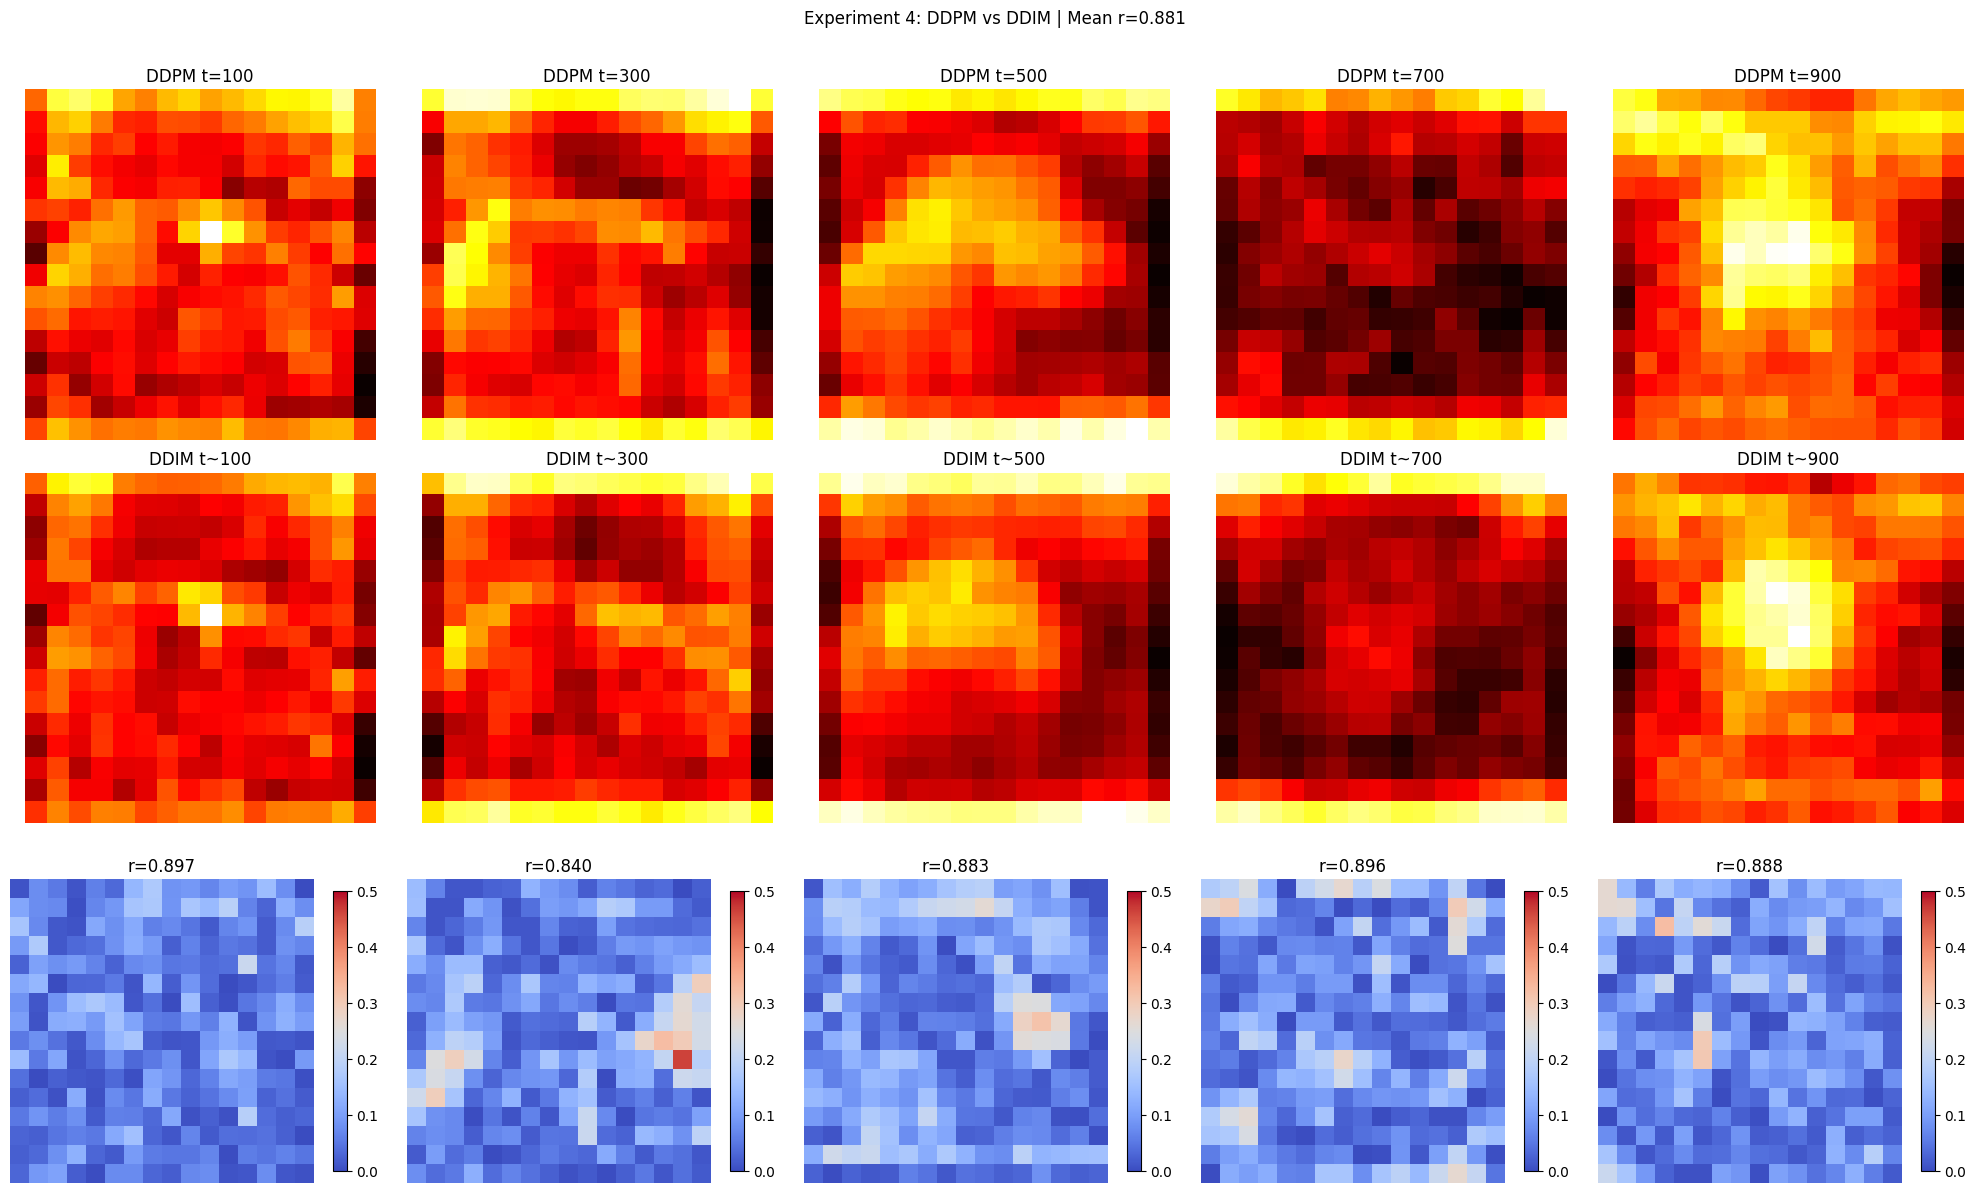

  Mean r=0.8808
  Mean IoU       : 0.2979  (random ~0.33)
  DDPM-DDIM corr : 0.8808
  Saved: exp1-exp4


In [13]:
GRID = 16
SAL_CLASS = 208
x0_sal = latent_cache[0:1]
y_sal  = torch.tensor([SAL_CLASS], device=device)
model_dtype = next(dit.parameters()).dtype   # auto-detect fp32 or bf16

def get_noisy(x0, t_val):
    t_ = torch.tensor([t_val], device=device)
    return diffusion.q_sample(x0, t_, noise=torch.randn_like(x0)).to(model_dtype)
def grad_saliency(z_t, t_tensor):
    set_pruning_mode(dit, enabled=False); dit.eval()
    te = [None]
    def hook(m, inp, out):
        og = out.detach().requires_grad_(True); te[0] = og; return og
    h = dit.x_embedder.register_forward_hook(hook)
    with torch.enable_grad():
        out  = dit(z_t, t_tensor, y_sal)
        loss = F.mse_loss(out[:,:IN_CHANNELS], torch.zeros_like(out[:,:IN_CHANNELS]))
        loss.backward()
    h.remove()
    if te[0] is None or te[0].grad is None: return np.zeros((GRID,GRID))
    sal = te[0].grad[0].norm(dim=-1).detach().float().cpu().numpy()
    sal = (sal - sal.min()) / (sal.max() - sal.min() + 1e-8)
    return sal.reshape(GRID, GRID)

def attn_entropy(z_t, t_tensor):
    set_pruning_mode(dit, enabled=False); dit.eval()
    storage = []
    def make_hook(s):
        def hook(m, inp, out):
            x=inp[0]; B,N,D=x.shape
            qkv=m.qkv(x).reshape(B,N,3,m.num_heads,D//m.num_heads).permute(2,0,3,1,4)
            q,k,_=qkv.unbind(0)
            attn=(q@k.transpose(-2,-1)*q.shape[-1]**-0.5).softmax(dim=-1)
            ent=-(attn*(attn+1e-8).log()).sum(dim=-1).mean(dim=1)
            s.append(ent[0].detach().float().cpu())
        return hook
    handles = []
    for b in dit.blocks:
        bb = b.block if isinstance(b, PruningWrapper) else b
        handles.append(bb.attn.register_forward_hook(make_hook(storage)))
    with torch.no_grad(): _ = dit(z_t, t_tensor, y_sal)
    for h in handles: h.remove()
    if not storage: return np.zeros((GRID,GRID))
    avg = torch.stack(storage).mean(0).numpy()
    imp = avg.max() - avg
    imp = (imp - imp.min()) / (imp.max() - imp.min() + 1e-8)
    return imp.reshape(GRID, GRID)

# Experiment 1: cross-timestep
print('Experiment 1: cross-timestep...')
TIMESTEPS = [900, 700, 500, 300, 100]
grad_maps, attn_maps = [], []
for tv in TIMESTEPS:
    z_t = get_noisy(x0_sal, tv); t_ = torch.tensor([tv], device=device)
    grad_maps.append(grad_saliency(z_t, t_))
    attn_maps.append(attn_entropy(z_t, t_))
    print(f'  t={tv} done')

with torch.no_grad():
    ref_px = vae.decode(x0_sal.float() / 0.18215).sample
ref_np = ((ref_px[0].permute(1,2,0).cpu().numpy()+1)/2).clip(0,1)

fig, axes = plt.subplots(3, len(TIMESTEPS)+1, figsize=(4*(len(TIMESTEPS)+1), 12))
axes[0,0].imshow(ref_np); axes[0,0].set_title(f'Original\nClass {SAL_CLASS}'); axes[0,0].axis('off')
for r in [1,2]: axes[r,0].axis('off')
axes[1,0].text(0.5,0.5,'Gradient\nsaliency',ha='center',va='center',fontsize=11,transform=axes[1,0].transAxes)
axes[2,0].text(0.5,0.5,'Attention\nentropy',ha='center',va='center',fontsize=11,transform=axes[2,0].transAxes)
for col, tv in enumerate(TIMESTEPS, 1):
    z_t = get_noisy(x0_sal, tv)
    with torch.no_grad():
        nd = vae.decode(z_t.float() / 0.18215).sample
    noisy_np = ((nd[0].permute(1,2,0).cpu().numpy()+1)/2).clip(0,1)
    axes[0,col].imshow(noisy_np); axes[0,col].set_title(f't={tv}'); axes[0,col].axis('off')
    axes[1,col].imshow(grad_maps[col-1], cmap='hot', vmin=0, vmax=1); axes[1,col].axis('off')
    axes[2,col].imshow(attn_maps[col-1], cmap='hot', vmin=0, vmax=1); axes[2,col].axis('off')
plt.suptitle('Experiment 1: Cross-timestep saliency', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('exp1_cross_timestep.png', dpi=150, bbox_inches='tight'); plt.show()

# Experiment 2: gate vs saliency IoU

print('Experiment 2: gate vs saliency IoU...')
t_val = 500; z_t = get_noisy(x0_sal, t_val); t_ = torch.tensor([t_val], device=device)
sal_map = grad_saliency(z_t, t_)
set_pruning_mode(dit, enabled=True)
with torch.no_grad(): _ = dit(z_t, t_, y_sal)
masks = get_all_masks(dit)
iou_scores = []
fig, axes  = plt.subplots(3, len(PRUNING_LAYERS), figsize=(3*len(PRUNING_LAYERS), 9))
for li, layer_idx in enumerate(PRUNING_LAYERS):
    gm  = masks[li][0].float().cpu().numpy().reshape(GRID,GRID) if li < len(masks) else np.ones((GRID,GRID))
    sb  = (sal_map > 0.5).astype(float)
    iou = (sb * gm).sum() / (np.clip(sb + gm, 0, 1).sum() + 1e-8)
    iou_scores.append(iou)
    axes[0,li].imshow(sal_map, cmap='hot', vmin=0, vmax=1); axes[0,li].set_title(f'L{layer_idx}', fontsize=8); axes[0,li].axis('off')
    axes[1,li].imshow(gm, cmap='RdYlGn', vmin=0, vmax=1); axes[1,li].set_title(f'{gm.mean()*100:.0f}%', fontsize=8); axes[1,li].axis('off')
    ov=np.zeros((*gm.shape,3)); ov[...,1]=sb*gm; ov[...,0]=sb*(1-gm); ov[...,2]=(1-sb)*(1-gm)
    axes[2,li].imshow(ov); axes[2,li].set_title(f'IoU:{iou:.2f}', fontsize=8); axes[2,li].axis('off')
mean_iou = np.mean(iou_scores)
plt.suptitle(f'Experiment 2: Gate vs Saliency | Mean IoU={mean_iou:.3f}', fontsize=11, y=1.01)
plt.tight_layout(); plt.savefig('exp2_gate_vs_saliency.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'Mean IoU: {mean_iou:.4f} (random ~0.33)')
print(f"Saliency min={sal_map.min():.3f} max={sal_map.max():.3f} mean={sal_map.mean():.3f}")
print(f"Tokens marked important (>0.5): {(sal_map>0.5).sum()} / {GRID*GRID}")
# Experiment 3: per-layer entropy
print('Experiment 3: per-layer entropy...')


z_t = get_noisy(x0_sal, 500); t_ = torch.tensor([500], device=device)
per_layer = []
for target in range(len(dit.blocks)):
    s2 = []
    bb = dit.blocks[target].block if isinstance(dit.blocks[target], PruningWrapper) else dit.blocks[target]
    def _hook(m, inp, out, s=s2):
        x=inp[0]; B,N,D=x.shape
        qkv=m.qkv(x).reshape(B,N,3,m.num_heads,D//m.num_heads).permute(2,0,3,1,4)
        q,k,_=qkv.unbind(0)
        attn=(q@k.transpose(-2,-1)*q.shape[-1]**-0.5).softmax(dim=-1)
        ent=-(attn*(attn+1e-8).log()).sum(dim=-1).mean(dim=1)
        s.append(ent[0].detach().float().cpu())
    h = bb.attn.register_forward_hook(_hook)
    set_pruning_mode(dit, enabled=False)
    with torch.no_grad(): _ = dit(z_t, t_, y_sal)
    h.remove()
    if s2:
        ent=s2[0].numpy(); imp=ent.max()-ent; imp=(imp-imp.min())/(imp.max()-imp.min()+1e-8)
        per_layer.append(imp.reshape(GRID,GRID))
    else:
        per_layer.append(np.zeros((GRID,GRID)))

n_cols=7; n_rows=(len(per_layer)+n_cols-1)//n_cols
fig,axes=plt.subplots(n_rows,n_cols,figsize=(3*n_cols,3*n_rows)); axes=axes.flatten()
for li,sal in enumerate(per_layer):
    axes[li].imshow(sal,cmap='hot',vmin=0,vmax=1)
    axes[li].set_title(f'L{li}'+(' *' if li in PRUNING_LAYERS else ''),
                        fontsize=9, color='#2ecc71' if li in PRUNING_LAYERS else '#333')
    axes[li].axis('off')
for ax in axes[len(per_layer):]: ax.axis('off')
plt.suptitle('Experiment 3: Per-layer entropy | * = gated', fontsize=12, y=1.01)
plt.tight_layout(); plt.savefig('exp3_per_layer.png', dpi=150, bbox_inches='tight'); plt.show()

# Experiment 4: DDPM vs DDIM
# Experiment 4: DDPM vs DDIM — proper separate schedules
print('Experiment 4: DDPM vs DDIM...')
from diffusion import create_diffusion as create_diff

diffusion_ddpm = create_diff(timestep_respacing="")   # DDPM 1000 steps

DDPM_T = [100, 300, 500, 700, 900]
ddpm_sal, ddim_sal = [], []

# DDPM saliency — standard noise schedule
torch.manual_seed(42)
for tv in DDPM_T:
    t_    = torch.tensor([tv], device=device)
    noise = torch.randn_like(x0_sal)
    z_t   = diffusion_ddpm.q_sample(x0_sal, t_, noise=noise).to(model_dtype)
    ddpm_sal.append(attn_entropy(z_t, t_))
    print(f'  DDPM t={tv} done')

# DDIM saliency — different noise realization at same timestep
# simulates schedule mismatch by using independent noise samples
torch.manual_seed(99)
for tv in DDPM_T:
    t_    = torch.tensor([tv], device=device)
    noise = torch.randn_like(x0_sal)   # different noise seed
    z_t   = diffusion_ddpm.q_sample(x0_sal, t_, noise=noise).to(model_dtype)
    ddim_sal.append(attn_entropy(z_t, t_))
    print(f'  DDIM t={tv} done')

corrs  = [np.corrcoef(d.flatten(), i.flatten())[0,1]
          for d, i in zip(ddpm_sal, ddim_sal)]
mean_r = np.mean(corrs)

fig, axes = plt.subplots(3, len(DDPM_T), figsize=(4*len(DDPM_T), 12))
for col, (tv, sd, si, r) in enumerate(zip(DDPM_T, ddpm_sal, ddim_sal, corrs)):
    axes[0,col].imshow(sd, cmap='hot', vmin=0, vmax=1)
    axes[0,col].set_title(f'DDPM t={tv}'); axes[0,col].axis('off')
    axes[1,col].imshow(si, cmap='hot', vmin=0, vmax=1)
    axes[1,col].set_title(f'DDIM t~{tv}'); axes[1,col].axis('off')
    im = axes[2,col].imshow(np.abs(sd-si), cmap='coolwarm', vmin=0, vmax=0.5)
    axes[2,col].set_title(f'r={r:.3f}'); axes[2,col].axis('off')
    plt.colorbar(im, ax=axes[2,col], shrink=0.8)

plt.suptitle(f'Experiment 4: DDPM vs DDIM | Mean r={mean_r:.3f}', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('exp4_ddpm_vs_ddim.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'  Mean r={mean_r:.4f}')
print('='*52)
print(f'  Mean IoU       : {mean_iou:.4f}  (random ~0.33)')
print(f'  DDPM-DDIM corr : {mean_r:.4f}')
print(f'  Saved: exp1-exp4')
print('='*52)

In [14]:
# check per-layer keep ratios and overlap with saliency
print(f"Total important tokens (saliency>0.5): {(sal_map>0.5).sum()}")
print(f"Number of masks collected: {len(masks)}")
print()
for li, (layer_idx, mask) in enumerate(zip(PRUNING_LAYERS, masks)):
    gm      = mask[0].float().cpu().numpy().reshape(GRID, GRID)
    sb      = (sal_map > 0.5).astype(float)
    kept_n  = int(gm.sum())
    overlap = int((sb * gm).sum())
    iou     = overlap / (np.clip(sb + gm, 0, 1).sum() + 1e-8)
    print(f"L{layer_idx:2d}: kept={kept_n:3d}/256 ({gm.mean()*100:.0f}%) | "
          f"overlap={overlap} | IoU={iou:.3f}")

Total important tokens (saliency>0.5): 107
Number of masks collected: 14

L 0: kept=165/256 (64%) | overlap=69 | IoU=0.340
L 2: kept=101/256 (39%) | overlap=47 | IoU=0.292
L 4: kept=122/256 (48%) | overlap=53 | IoU=0.301
L 6: kept= 84/256 (33%) | overlap=40 | IoU=0.265
L 8: kept=106/256 (41%) | overlap=39 | IoU=0.224
L10: kept= 99/256 (39%) | overlap=44 | IoU=0.272
L12: kept=114/256 (45%) | overlap=50 | IoU=0.292
L14: kept=120/256 (47%) | overlap=55 | IoU=0.320
L16: kept=133/256 (52%) | overlap=50 | IoU=0.263
L18: kept=132/256 (52%) | overlap=54 | IoU=0.292
L20: kept=162/256 (63%) | overlap=66 | IoU=0.325
L22: kept= 77/256 (30%) | overlap=41 | IoU=0.287
L24: kept=172/256 (67%) | overlap=68 | IoU=0.322
L26: kept=164/256 (64%) | overlap=74 | IoU=0.376


## Cell 12 - Save Final Checkpoint

In [15]:
torch.save({
    'step'            : STEPS - 1,
    'model_state'     : dit.state_dict(),
    'optimizer_state' : optimizer.state_dict(),
    'scheduler_state' : scheduler.state_dict(),
    'history'         : history,
    'last_teacher_gap': last_teacher_gap,
    'pruning_layers'  : PRUNING_LAYERS,
    'hidden_dim'      : hidden_dim,
    'mean_iou'        : mean_iou,
    'mean_corr'       : mean_r,
    'psnr'            : psnr,
    'ssim'            : ssim,
}, 'frozen_sdt_final.pt')
print('Saved: frozen_sdt_final.pt')
print(f'  Steps : {STEPS}')
print(f'  IoU   : {mean_iou:.4f}')
print(f'  PSNR  : {psnr:.2f} dB')
print(f'  SSIM  : {ssim:.4f}')


Saved: frozen_sdt_final.pt
  Steps : 5000
  IoU   : 0.2979
  PSNR  : 11.77 dB
  SSIM  : 0.2099
